# Introduction
The maps you create in this course portray the surface of the earth in two dimensions. But, as you know, the world is actually a three-dimensional globe. So we have to use a method called a map projection to render it as a flat surface.

Map projections can't be 100% accurate. Each projection distorts the surface of the Earth in some way, while retaining some useful property. For instance,

- the equal-area projections (like "Lambert Cylindrical Equal Area", or "Africa Albers Equal Area Conic") preserve area. This is a good choice, if you'd like to calculate the area of a country or city, for example.
- the equidistant projections (like "Azimuthal Equidistant projection") preserve distance. This would be a good choice for calculating flight distance.

We use a coordinate reference system (CRS) to show how the projected points correspond to real locations on Earth. In this tutorial, you'll learn more about coordinate reference systems, along with how to use them in GeoPandas.

In [1]:
import geopandas as gpd
import pandas as pd
from pandas.core.groupby import categorical
from pyprojroot.here import here

#Setting the CRS

When we create a GeoDataFrame from a shapefile, the CRS is already imported for us.

In [2]:
# Load a GeoDataFrame containing regions in Ghana
regions = gpd.read_file(here("data/ghana/ghana/Regions/Map_of_Regions_in_Ghana.shp"))
print(regions.crs)

EPSG:32630


Coordinate reference systems are referenced by [European Petroleum Survey Group](http://www.epsg.org/) (EPSG) codes.

This GeoDataFrame uses EPSG 32630, which is more commonly called the "Mercator" projection. This projection preserves angles (making it useful for sea navigation) and slightly distorts area.

However, when creating a GeoDataFrame from a CSV file, we have to set the CRS. [EPSG 4326](https://epsg.io/4326) corresponds to coordinates in latitude and longitude.

In [3]:
# Create a DataFrame with health facilities in Ghana
facilities_df = pd.read_csv(here("data/ghana/ghana/health_facilities.csv"))

# Convert the DataFrame to a GeoDataFrame
facilities = gpd.GeoDataFrame(facilities_df, geometry=gpd.points_from_xy(facilities_df.Longitude, facilities_df.Latitude))

# Set the coordinate reference system (CRS) to EPSG 4326
# facilities.crs = {'init': 'epsg:4326'} # deprecated syntax
facilities.crs = 'epsg:4326'

# View the first five rows of the GeoDataFrame
facilities.head()

,Region,District,FacilityName,Type,Town,Ownership,Latitude,Longitude,geometry
0,Ashanti,Offinso North,A.M.E Zion Clinic,Clinic,Afrancho,CHAG,7.40801,-1.96317,POINT (-1.96317 7.40801)
1,Ashanti,Bekwai Municipal,Abenkyiman Clinic,Clinic,Anwiankwanta,Private,6.46312,-1.58592,POINT (-1.58592 6.46312)
2,Ashanti,Adansi North,Aboabo Health Centre,Health Centre,Aboabo No 2,Government,6.22393,-1.34982,POINT (-1.34982 6.22393)
3,Ashanti,Afigya-Kwabre,Aboabogya Health Centre,Health Centre,Aboabogya,Government,6.84177,-1.61098,POINT (-1.61098 6.84177)
4,Ashanti,Kwabre,Aboaso Health Centre,Health Centre,Aboaso,Government,6.84177,-1.61098,POINT (-1.61098 6.84177)


## Re-projecting
Re-projecting refers to the process of changing the CRS. This is done in GeoPandas with the `to_crs()` method.

When plotting multiple GeoDataFrames, it's important that they all use the same CRS. In the code cell below, we change the CRS of the facilities GeoDataFrame to match the CRS of regions before plotting it.

<Axes: >

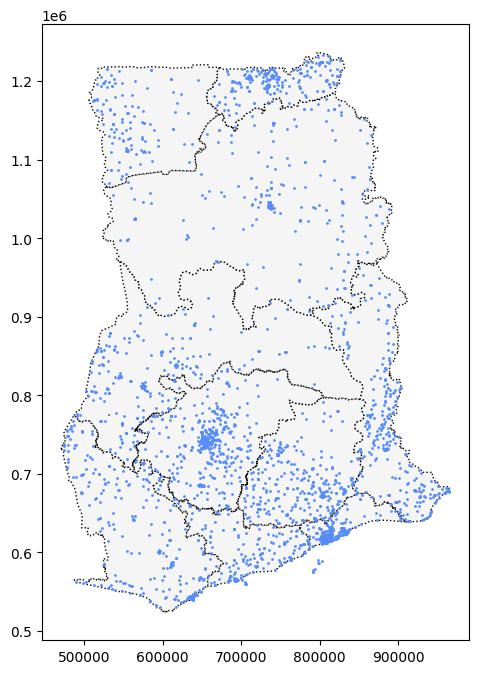

In [4]:
# Create a map
ax = regions.plot(figsize=(8,8), color='whitesmoke', linestyle=':', edgecolor='black')
facilities.to_crs(epsg=32630).plot(markersize=1, ax=ax)

The to_crs() method modifies only the "geometry" column: all other columns are left as-is.

In [5]:
# The "Latitude" and "Longitude" columns are unchanged
facilities.to_crs(epsg=32630).head()

,Region,District,FacilityName,Type,Town,Ownership,Latitude,Longitude,geometry
0,Ashanti,Offinso North,A.M.E Zion Clinic,Clinic,Afrancho,CHAG,7.40801,-1.96317,POINT (614422.662 818986.851)
1,Ashanti,Bekwai Municipal,Abenkyiman Clinic,Clinic,Anwiankwanta,Private,6.46312,-1.58592,POINT (656373.863 714616.547)
2,Ashanti,Adansi North,Aboabo Health Centre,Health Centre,Aboabo No 2,Government,6.22393,-1.34982,POINT (682573.395 688243.477)
3,Ashanti,Afigya-Kwabre,Aboabogya Health Centre,Health Centre,Aboabogya,Government,6.84177,-1.61098,POINT (653484.49 756478.812)
4,Ashanti,Kwabre,Aboaso Health Centre,Health Centre,Aboaso,Government,6.84177,-1.61098,POINT (653484.49 756478.812)


In case the EPSG code is not available in GeoPandas, we can change the CRS with what's known as the "proj4 string" of the CRS. For instance, the proj4 string to convert to latitude/longitude coordinates is as follows:

`+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs`

In [6]:
# Change the CRS to EPSG 4326
regions.to_crs("+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs").head()

,Region,geometry
0,Ashanti,"POLYGON ((-1.30985 7.62302, -1.30786 7.62198, ..."
1,Brong Ahafo,"POLYGON ((-2.54567 8.76089, -2.54473 8.76071, ..."
2,Central,"POLYGON ((-2.06723 6.29473, -2.06658 6.2942, -..."
3,Eastern,"POLYGON ((-0.21751 7.21009, -0.21747 7.20993, ..."
4,Greater Accra,"POLYGON ((0.23456 6.10986, 0.23484 6.10974, 0...."


## Attributes of geometric objects
As you learned in the first tutorial, for an arbitrary GeoDataFrame, the type in the "geometry" column depends on what we are trying to show: for instance, we might use:

- a Point for the epicenter of an earthquake,
- a LineString for a street, or
- a Polygon to show country boundaries.
All three types of geometric objects have built-in attributes that you can use to quickly analyze the dataset. For instance, you can get the x- and y-coordinates of a Point from the `x` and `y` attributes, respectively.

In [7]:
# Get the x-coordinate of each point
facilities.geometry.head().x

0   -1.96317
1   -1.58592
2   -1.34982
3   -1.61098
4   -1.61098
dtype: float64

And, you can get the length of a LineString from the `length` attribute.

Or, you can get the area of a Polygon from the `area` attribute.

In [8]:
# Calculate the area (in square meters) of each polygon in the GeoDataFrame
regions.loc[:, "AREA"] = regions.geometry.area / 10**6

print("Area of Ghana: {} square kilometers".format(regions.AREA.sum()))
print("CRS:", regions.crs)
regions.head()

Area of Ghana: 239584.5760055668 square kilometers
CRS: EPSG:32630


,Region,geometry,AREA
0,Ashanti,"POLYGON ((686446.075 842986.894, 686666.193 84...",24379.017777
1,Brong Ahafo,"POLYGON ((549970.457 968447.094, 550073.003 96...",40098.168231
2,Central,"POLYGON ((603176.584 695877.238, 603248.424 69...",9665.626760
3,Eastern,"POLYGON ((807307.254 797910.553, 807311.908 79...",18987.625847
4,Greater Accra,"POLYGON ((858081.638 676424.913, 858113.115 67...",3706.511145


In the code cell above, since the CRS of the regions GeoDataFrame is set to EPSG 32630 (a "Mercator" projection), the area calculation is slightly less accurate than if we had used an equal-area projection like "Africa Albers Equal Area Conic".

But this yields the area of Ghana as approximately 239585 square kilometers, which is not too far off from the correct answer.

# Exercises

## Introduction
You are a bird conservation expert and want to understand migration patterns of purple martins. In your research, you discover that these birds typically spend the summer breeding season in the eastern United States, and then migrate to South America for the winter. But since this bird is under threat of endangerment, you'd like to take a closer look at the locations that these birds are more likely to visit.

There are several protected areas in South America, which operate under special regulations to ensure that species that migrate (or live) there have the best opportunity to thrive. You'd like to know if purple martins tend to visit these areas. To answer this question, you'll use some recently collected data that tracks the year-round location of eleven different birds.

In [2]:
import pandas as pd
import geopandas as gpd
# from geodatasets import get_path
# import geodatasets as gds
from pyprojroot import here
from shapely.geometry import LineString

# Exercises

### 1) Load the data.

Run the next code cell (without changes) to load the GPS data into a pandas DataFrame `birds_df`.

In [3]:
# Load the data and print the first 5 rows
birds_df = pd.read_csv(here("data/purple_martin.csv"), parse_dates=['timestamp'])
print("There are {} different birds in the dataset.".format(birds_df["tag-local-identifier"].nunique()))
birds_df.head()

There are 11 different birds in the dataset.


,timestamp,location-long,location-lat,tag-local-identifier
0,2014-08-15 05:56:00,-88.146014,17.513049,30448
1,2014-09-01 05:59:00,-85.243501,13.095782,30448
2,2014-10-30 23:58:00,-62.906089,-7.852436,30448
3,2014-11-15 04:59:00,-61.776826,-11.723898,30448
4,2014-11-30 09:59:00,-61.241538,-11.612237,30448


There are 11 birds in the dataset, where each bird is identified by a unique value in the "tag-local-identifier" column.  Each bird has several measurements, collected at different times of the year.

Use the next code cell to create a GeoDataFrame `birds`.
- `birds` should have all of the columns from `birds_df`, along with a "geometry" column that contains Point objects with (longitude, latitude) locations.
- Set the CRS of `birds` to `{'init': 'epsg:4326'}`.

In [4]:
birds = gpd.GeoDataFrame(birds_df, geometry=gpd.points_from_xy(birds_df['location-long'], birds_df['location-lat']))

# Set the coordinate reference system (CRS) to EPSG 4326
birds.crs = 'epsg:4326'

### 2) Plot the data.

Next, we load in the `'naturalearth_lowres'` dataset from GeoPandas, and set `americas` to a GeoDataFrame containing the boundaries of all countries in the Americas (both North and South America).  Run the next code cell without changes.

In [5]:
# Load a GeoDataFrame with country boundaries in North/South America, print the first 5 rows
ne_world = gpd.read_file(here("data/tmap_World/tmap_World.shp"))
americas = ne_world.loc[ne_world['continent'].isin(['North America', 'South America'])]

<Axes: >

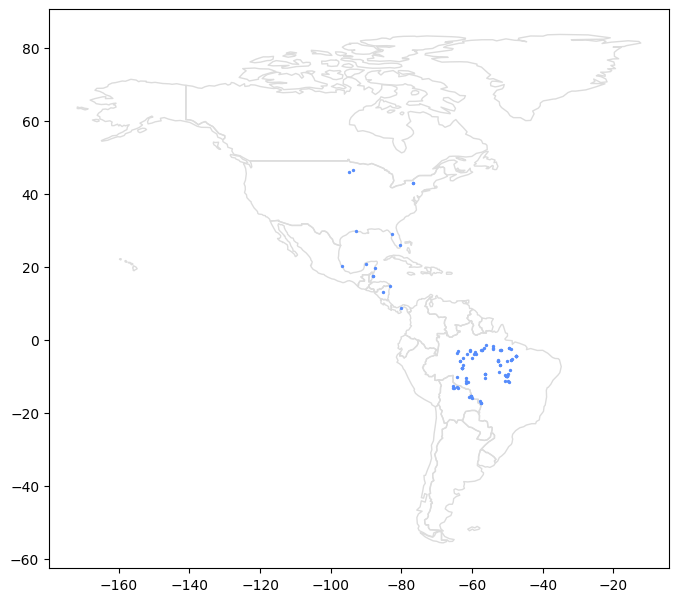

In [6]:
ax = americas.plot(figsize=(8,8), color = 'none', edgecolor='gainsboro')
birds.plot(markersize=2, ax=ax)

### 3) Where does each bird start and end its journey? (Part 1)

Now, we're ready to look more closely at each bird's path.  Run the next code cell to create two GeoDataFrames:
- `path_gdf` contains LineString objects that show the path of each bird.  It uses the `LineString()` method to create a LineString object from a list of Point objects.
- `start_gdf` contains the starting points for each bird.

In [7]:
# GeoDataFrame showing path for each bird
path_df = birds.groupby("tag-local-identifier")['geometry'].apply(list).apply(lambda x: LineString(x)).reset_index()
path_gdf = gpd.GeoDataFrame(path_df, geometry=path_df.geometry)
path_gdf.crs = 'epsg:4326'

# GeoDataFrame showing starting point for each bird
start_df = birds.groupby("tag-local-identifier")['geometry'].apply(list).apply(lambda x: x[0]).reset_index()
start_gdf = gpd.GeoDataFrame(start_df, geometry=start_df.geometry)
start_gdf.crs = 'epsg:4326'

# Show first five rows of GeoDataFrame
start_gdf.head()

,tag-local-identifier,geometry
0,30048,POINT (-90.12992 20.73242)
1,30054,POINT (-93.60861 46.50563)
2,30198,POINT (-80.31036 25.92545)
3,30263,POINT (-76.78146 42.99208)
4,30275,POINT (-76.78213 42.99207)


Use the next code cell to create a GeoDataFrame `end_gdf` containing the final location of each bird.
- The format should be identical to that of `start_gdf`, with two columns ("tag-local-identifier" and "geometry"), where the "geometry" column contains Point objects.
- Set the CRS of `end_gdf` to `{'init': 'epsg:4326'}`.

In [8]:
end_df = birds.groupby("tag-local-identifier")['geometry'].apply(list).apply(lambda x: x[-1]).reset_index()
end_gdf = gpd.GeoDataFrame(start_df, geometry=end_df.geometry)
end_gdf.crs = 'epsg:4326'

end_gdf.head()

,tag-local-identifier,geometry
0,30048,POINT (-47.53632 -4.43758)
1,30054,POINT (-62.47914 -5.0384)
2,30198,POINT (-57.46417 -2.77617)
3,30263,POINT (-50.1923 -5.70504)
4,30275,POINT (-57.70404 -16.72336)


### 4) Where does each bird start and end its journey? (Part 2)

Use the GeoDataFrames from the question above (`path_gdf`, `start_gdf`, and `end_gdf`) to visualize the paths of all birds on a single map.  You may also want to use the `americas` GeoDataFrame.

<Axes: >

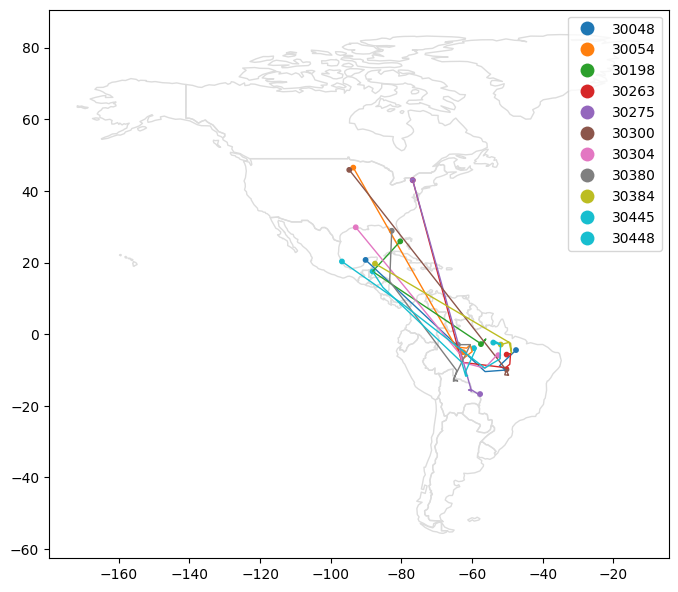

In [23]:
ax = americas.plot(figsize=(8,8), color = 'none', edgecolor='gainsboro')
start_gdf.plot(column = 'tag-local-identifier', markersize=10, categorical = True, ax=ax)
path_gdf.plot(column = 'tag-local-identifier', linewidth = 1, categorical = True, legend = True, ax=ax)
end_gdf.plot(column = 'tag-local-identifier', markersize=10, categorical = True, ax=ax)


### 5) Where are the protected areas in South America? (Part 1)

It looks like all of the birds end up somewhere in South America.  But are they going to protected areas?

In the next code cell, you'll create a GeoDataFrame `protected_areas` containing the locations of all of the protected areas in South America.  The corresponding shapefile is located at filepath `protected_filepath`.

In [24]:
protected_filepath = here("data/SAPA_Aug2019-shapefile/SAPA_Aug2019-shapefile/SAPA_Aug2019-shapefile-polygons.shp")
protected_areas = gpd.read_file(protected_filepath)


### 6) Where are the protected areas in South America? (Part 2)

Create a plot that uses the `protected_areas` GeoDataFrame to show the locations of the protected areas in South America.  (_You'll notice that some protected areas are on land, while others are in marine waters._)

In [41]:
# Country boundaries in South America
south_america = americas.loc[americas['continent']=='South America']


<Axes: >

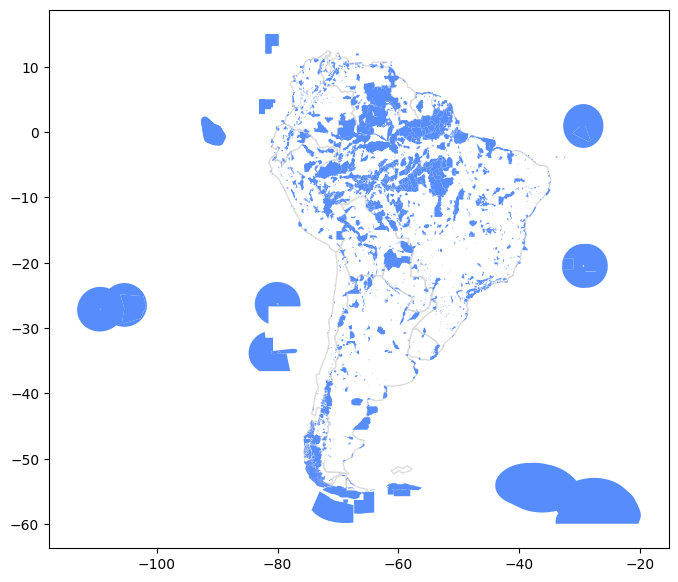

In [28]:
ax = south_america.plot(figsize=(8,8), color = 'none', edgecolor='gainsboro')
protected_areas.plot(ax=ax)

### 7) What percentage of South America is protected?

You're interested in determining what percentage of South America is protected, so that you know how much of South America is suitable for the birds.

As a first step, you calculate the total area of all protected lands in South America (not including marine area).  To do this, you use the "REP_AREA" and "REP_M_AREA" columns, which contain the total area and total marine area, respectively, in square kilometers.

Run the code cell below without changes.

In [29]:
P_Area = sum(protected_areas['REP_AREA']-protected_areas['REP_M_AREA'])
print("South America has {} square kilometers of protected areas.".format(P_Area))

South America has 5396761.911688372 square kilometers of protected areas.


Then, to finish the calculation, you'll use the `south_america` GeoDataFrame.

In [30]:
south_america.head()

,iso_a3,name,sovereignt,continent,area,pop_est,pop_est_de,economy,income_grp,gdp_cap_es,life_exp,well_being,footprint,HPI,inequality,gender,press,geometry
5,ARG,Argentina,Argentina,South America,2.783123e+06,44938712.0,16.146863,5. Emerging region: G20,3. Upper middle income,9912.277860,75.390,5.908279,6.391003,43.792331,40.7,0.292,63.13,"MULTIPOLYGON (((-68.634 -52.636, -68.25 -53.1,..."
17,BOL,Bolivia,Bolivia,South America,1.090457e+06,11513100.0,10.558047,5. Emerging region: G20,4. Lower middle income,3552.040719,63.630,5.568624,5.875921,32.070783,40.9,0.418,48.88,"POLYGON ((-68.665 -12.561, -69.53 -10.952, -68..."
20,BRA,Brazil,Brazil,South America,8.504961e+06,211049527.0,24.814872,3. Emerging region: BRIC,3. Upper middle income,8717.186085,72.750,6.009953,4.586593,46.172934,52.0,0.391,58.59,"POLYGON ((-52.712 -33.197, -53.374 -33.768, -5..."
30,CHL,Chile,Chile,South America,7.363625e+05,18952038.0,25.737376,5. Emerging region: G20,3. Upper middle income,14896.445438,78.944,6.435631,6.202551,51.265938,43.0,0.190,67.32,"MULTIPOLYGON (((-68.634 -52.636, -68.633 -54.8..."
32,COL,Colombia,Colombia,South America,1.140095e+06,50339443.0,44.153714,6. Developing region,3. Upper middle income,6428.656749,72.830,5.289958,3.738341,42.936471,54.8,0.392,49.63,"POLYGON ((-67.181 2.251, -66.876 1.253, -67.06..."


Calculate the total area of South America by following these steps:
- Calculate the area of each country using the `area` attribute of each polygon (with EPSG 3035 as the CRS), and add up the results.  The calculated area will be in units of square meters.
- Convert your answer to have units of square kilometeters.

In [42]:
totalArea = south_america.to_crs(epsg=3035).geometry.area.sum() / 10**6
print(totalArea)

17759016.304549586


In [43]:
# What percentage of South America is protected?
percentage_protected = P_Area/totalArea
print('Approximately {}% of South America is protected.'.format(round(percentage_protected*100, 2)))

Approximately 30.39% of South America is protected.


### 8) Where are the birds in South America?

So, are the birds in protected areas?

Create a plot that shows for all birds, all of the locations where they were discovered in South America.  Also plot the locations of all protected areas in South America.

To exclude protected areas that are purely marine areas (with no land component), you can use the "MARINE" column (and plot only the rows in `protected_areas[protected_areas['MARINE']!='2']`, instead of every row in the `protected_areas` GeoDataFrame).

<Axes: >

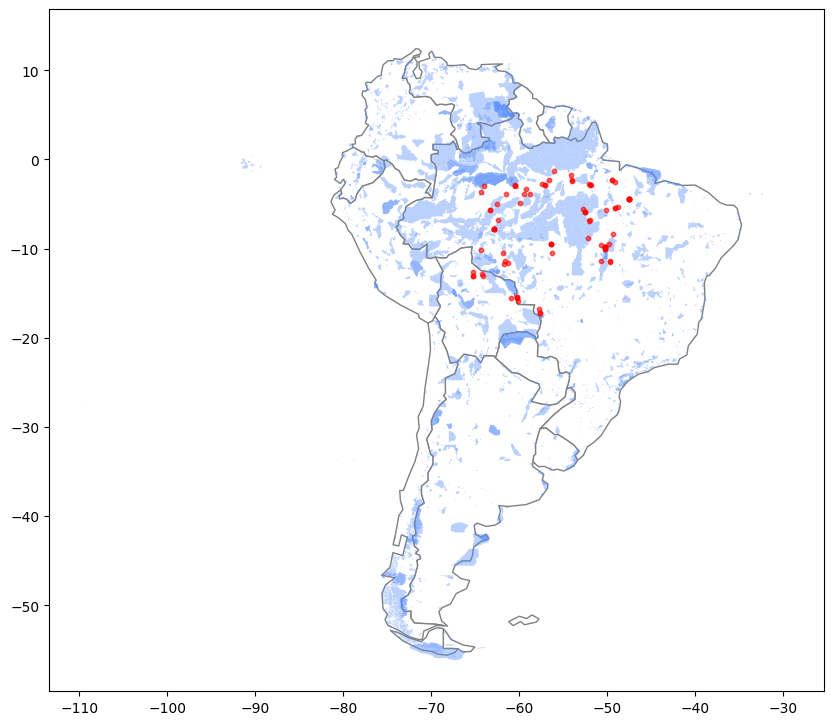

In [48]:
nom_protected_areas = protected_areas[protected_areas['MARINE']!='2']

ax = south_america.plot(figsize=(10,10), color='white', edgecolor='gray')
nom_protected_areas.plot(ax=ax, alpha=0.4, zorder=1)
birds[birds.geometry.y < 0].plot(ax=ax, color='red', alpha=0.6, markersize=10, zorder=2)
